In [24]:
import os

import numpy as np
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt

import imn_generation
import imn_loading
from map_matching import (map_match_valhalla_all,
                          points_to_osmnx_routes,
                          read_osmnx_routes)
from experiments.trajectory_analysis import (dtw_overlap_all,
                                             get_route_edge_attributes,
                                             get_adjusted_edge_attributes)
from personalized_routing import (add_edge_attributes,
                                  compare_fastest,
                                  learn_user_preferences)

# Loading the data
Trajectory data is assumed to be GPS traces, in tabular format, with columns `userid`, `timestamp`, `latitude`, and `longitude`. This data is read, and the graph that covers the area of interest is downloaded from OpenStreetMap.

In [29]:
# Using a sample dataset of Milan, Italy
points_df = pd.read_csv('data/sample_Milan_2007.csv.gz').rename(columns={
    'userid':'id', 
    'datetime':'timestamp',
    'lon':'longitude', 
    'lat':'latitude'
})

# Convert timestamp string to Epoch in seconds
points_df['timestamp'] = pd.to_datetime(points_df['timestamp']).values.astype(np.int64) // 10 ** 9
points_df.head()

,id,timestamp,latitude,longitude
0,1059,1175759222,45.474777,9.210948
1,1059,1175760960,45.474777,9.210948
2,1059,1175762693,45.474777,9.210948
3,1059,1175782974,45.474777,9.210948
4,1059,1175794229,45.474777,9.210948


In [30]:
points_df.shape

(99999, 4)

In [31]:
# Download and save the OSM graph for the area of interest
# Buffer around to avoid cutting off edges at the border
bufsize = 0.01
bbox = (np.min(points_df['longitude'] - bufsize),
         np.min(points_df['latitude'] - bufsize),
         np.max(points_df['longitude'] + bufsize),
         np.max(points_df['latitude'] + bufsize))

G = ox.graph_from_bbox(bbox, network_type='drive', simplify=False)

# Keep only the largest strongly connected component
G = ox.truncate.largest_component(G, strongly=True)

# Add:
# - residential/motorway (binary variables)
# - area of landuse (industrial, commercial, residential, green areas, water areas)
# - POI type counts, categorized by stop length/flow intensity (short, medium, high/low, medium, high)
G = add_edge_attributes(G)
ox.save_graphml(G, 'data/milano_2007_graph.graphml')

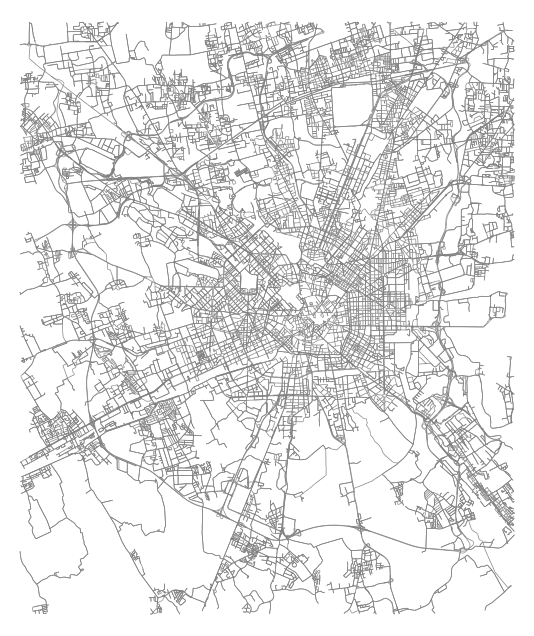

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [32]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.5, edge_color='gray', bgcolor='white', show=True)

# Constructing the IMN + map-matching

In [ ]:
# IMN generation takes care of segmentation (tau_s = 50 m, tau_t = 1200 s)
# Also removes large errors in trajectories with a max speed threshold of 252 km/s
# Also discards users with too little history (< 10 trajs)
imn_generation.main_from_code(points_df, 'data/milano_2007_imns.json.gz')

--- 0.19730901718139648 seconds Location Extraction ---
IMN created for 650 with 11 trajectories
--- 0.288470983505249 seconds Location Extraction ---
IMN created for 1575 with 16 trajectories
--- 0.11234307289123535 seconds Location Extraction ---
IMN created for 1607 with 11 trajectories
--- 0.3289179801940918 seconds Location Extraction ---
IMN created for 2133 with 12 trajectories
--- 0.20944690704345703 seconds Location Extraction ---
IMN created for 2565 with 18 trajectories
--- 0.2043781280517578 seconds Location Extraction ---
IMN created for 3695 with 11 trajectories
--- 0.14929986000061035 seconds Location Extraction ---
IMN created for 3703 with 12 trajectories
--- 0.1427931785583496 seconds Location Extraction ---
IMN created for 5892 with 16 trajectories
--- 0.16150307655334473 seconds Location Extraction ---
IMN created for 5902 with 11 trajectories
--- 0.1948540210723877 seconds Location Extraction ---
IMN created for 7308 with 13 trajectories
--- 0.47687292098999023 sec

In [2]:
imns = imn_loading.read_imn('data/milano_2007_imns.json.gz')
segmented_trajs = imn_loading.get_trajectories_from_imns(imns)

In [4]:
# 1st step: map-match
# Must have constructed the tile extracts for Valhalla in advance, see README
map_match_valhalla_all(segmented_trajs,
                       output_path='data/milano_2007_mapmatched.csv.gz',
                       tile_extract='valhalla/valhalla_tiles.tar',
                       verbose=True)

Starting Valhalla map-matching
Users:   0%|          | 0/248 [00:00<?, ?it/s]

Users: 100%|██████████| 248/248 [07:11<00:00,  1.74s/it]
Valhalla map-matching completed


In [5]:
# 2nd step: convert map-matched points to OSMnx routes
G = ox.load_graphml('data/milano_2007_graph.graphml')
points_to_osmnx_routes(G,
                       input_path='data/milano_2007_mapmatched.csv.gz',
                       output_path='data/milano_2007_routes.csv.gz',
                       verbose=True)

Starting conversion to osmnx routes
Users: 100%|██████████| 248/248 [00:33<00:00,  7.33it/s]
Conversion to osmnx routes completed


In [25]:
routes = read_osmnx_routes('data/milano_2007_routes.csv.gz')

In [30]:
# Example of a route: it stores start + end timestamps and traversed nodes
print(routes[650][0]['start_timestamp'])
print(routes[650][0]['end_timestamp'])
print(routes[650][0]['nodes'][0:9])

1175753856
1175754597
[12877870309, 12877870308, 12877870309, 3028366658, 1841346140, 2550433826, 2550433823, 253752169, 1555859669]


### Example route visualization
Plotting the same route: before map-matching and after map-matching

In [15]:
from experiments.trajectory_analysis import get_route_bbox

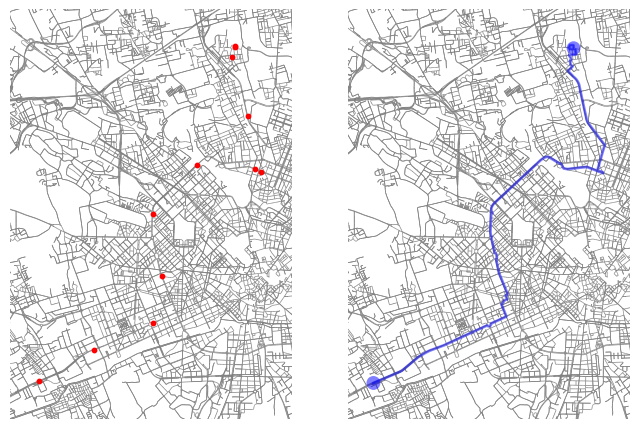

In [25]:
orig_route = segmented_trajs[650].query('id == 8')
osmnx_route = routes[650][8]['nodes']

bbox = get_route_bbox(G, [osmnx_route])

# Original points
fig, ax = plt.subplots(1,2, figsize=(8,6))
ox.plot_graph(G, ax=ax[0],
              edge_color='gray',
              bgcolor='white',
              edge_linewidth=0.5, node_size=0,
              bbox=bbox,
              close=False,
              show=False)
ax[0].scatter(orig_route['longitude'], orig_route['latitude'], c='red', s=10)

# Route
ox.plot_graph(
    G, ax=ax[1],
    edge_color='gray', bgcolor='white',
    edge_linewidth=0.5, node_size=0,
    bbox=bbox, close=False, show=False
)
ox.plot_graph_route(G, osmnx_route, ax=ax[1],
                    route_color='blue',
                    edge_color='gray',
                    bgcolor='white',
                    edge_linewidth=0.5,
                    route_linewidth=2, node_size=0,
                    bbox=bbox,
                    close=False,
                    show=False)

plt.show()

# Data exploration
Comparing real routes with different single-cost optimizing routes

In [2]:
G = ox.load_graphml('data/milano_2007_graph.graphml')
routes = read_osmnx_routes('data/milano_2007_routes.csv.gz')

### DTW / Jaccard

In [3]:
dtw_overlap_all(G,
                routes,
                filename='data/milano_2007_dtw_overlap.csv.gz',
                num_processes=1,
                verbose=True)

Users: 100%|██████████| 248/248 [24:46<00:00,  5.99s/it]


In [16]:
dtw_overlap = pd.read_csv('data/milano_2007_dtw_overlap.csv.gz')
dtw_overlap.head()

,uid,tid,dtw_travel_time,dtw_length,dtw_speed_kph,dtw_residential,dtw_motorway,dtw_random,overlap_travel_time,overlap_length,overlap_speed_kph,overlap_residential,overlap_motorway,overlap_random,spherical_dist_o_d
0,650,0,0.615137,0.615137,0.615137,0.615137,182.245033,0.615137,0.965517,0.965517,0.965517,0.965517,0.108108,0.965517,593.027722
1,650,1,49.355143,49.355143,89.300059,191.525527,75.381646,89.300059,0.490494,0.490494,0.526549,0.276231,0.449393,0.526549,2278.547983
2,650,2,916.417650,916.417650,752.818635,5392.753067,940.601688,751.295474,0.014953,0.014953,0.194444,0.031573,0.015444,0.195804,2220.618548
3,650,3,20.975493,20.975493,513.664682,625.014372,1440.555205,730.073503,0.587896,0.587896,0.149746,0.026690,0.013032,0.034483,3337.447192
4,650,4,126.109838,295.460534,377.808833,297.242235,348.004726,275.679276,0.486166,0.187179,0.036313,0.151304,0.051852,0.102410,3301.370661


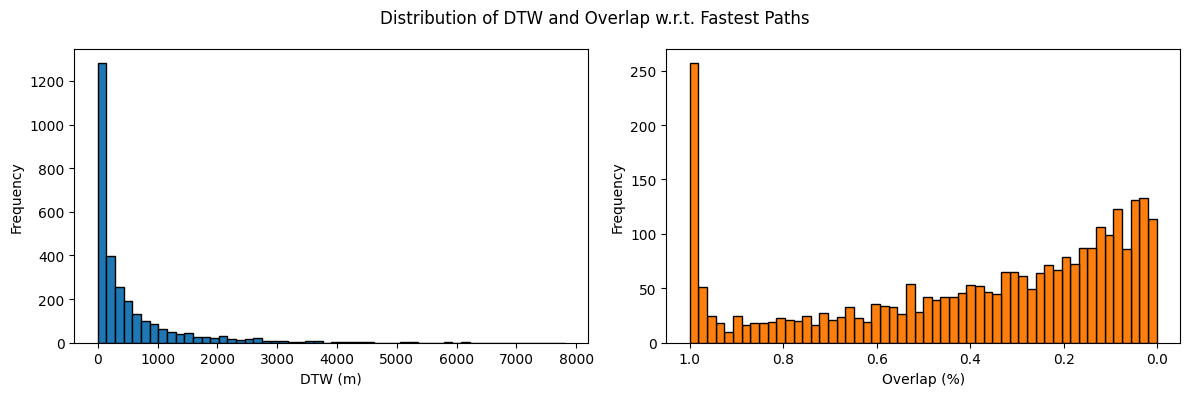

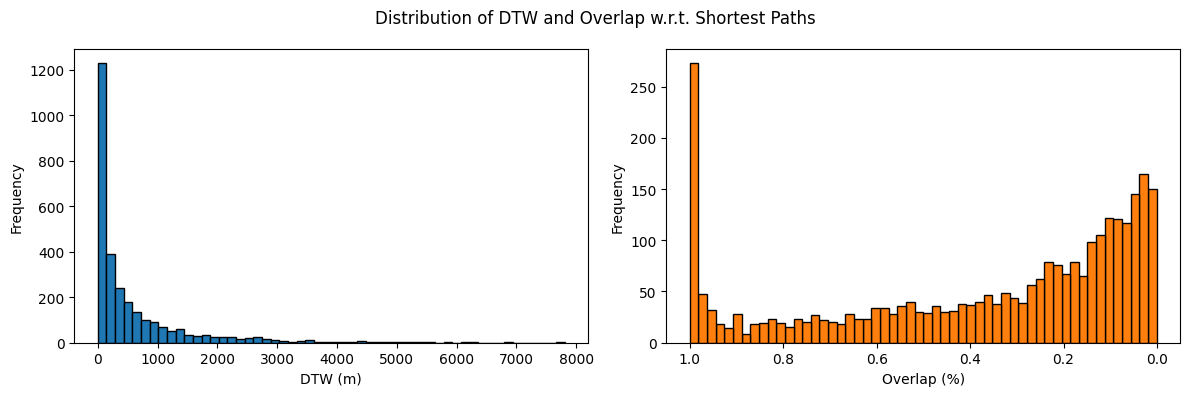

In [5]:
# Distribution of DTW and Jaccard
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(dtw_overlap['dtw_travel_time'], bins='sqrt', edgecolor='black', color='tab:blue')
ax[0].set_xlabel('DTW (m)')
ax[0].set_ylabel('Frequency')

ax[1].hist(dtw_overlap['overlap_travel_time'], bins='sqrt', edgecolor='black', color='tab:orange')
ax[1].invert_xaxis()
ax[1].set_xlabel('Overlap (%)')
ax[1].set_ylabel('Frequency')

fig.suptitle('Distribution of DTW and Overlap w.r.t. Fastest Paths')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(dtw_overlap['dtw_length'], bins='sqrt', edgecolor='black', color='tab:blue')
ax[0].set_xlabel('DTW (m)')
ax[0].set_ylabel('Frequency')

ax[1].hist(dtw_overlap['overlap_length'], bins='sqrt', edgecolor='black', color='tab:orange')
ax[1].invert_xaxis()
ax[1].set_xlabel('Overlap (%)')
ax[1].set_ylabel('Frequency')

fig.suptitle('Distribution of DTW and Overlap w.r.t. Shortest Paths')
plt.tight_layout()
plt.show()

### Edge-by-edge attributes
Full collection of attributes from each edge traversed by all routes in the data, no aggregation

In [6]:
get_route_edge_attributes(G,
                          routes,
                          center={'y': 45.46823695109099, 'x': 9.182262786187506},
                          filename_real='data/milano_2007_attr_real.csv.gz',
                          filename_fastest='data/milano_2007_attr_fastest.csv.gz',
                          verbose=True)

Users: 100%|██████████| 248/248 [04:32<00:00,  1.10s/it]


In [7]:
real_df = pd.read_csv('data/milano_2007_attr_real.csv.gz')
fastest_df = pd.read_csv('data/milano_2007_attr_fastest.csv.gz')

In [11]:
real_df.head()

,uid,tid,start_weekday,start_hour,route_dist_o_d,route_dist_o_center,route_dist_d_center,edge_dist_center,length,speed_kph,...,stop_medium,stop_long,flow_low,flow_medium,flow_high,water,landuse_green,landuse_commercial,landuse_residential,landuse_industrial
0,650,0,Thursday,8,593.027722,4994.134485,4437.731167,5002.693149,18.454138,50.0,...,0.0,2.0,0.0,0.0,2.0,0.0,9.920619,0.0,13.468512,0.0
1,650,0,Thursday,8,593.027722,4994.134485,4437.731167,5002.693149,18.454138,50.0,...,0.0,2.0,0.0,0.0,2.0,0.0,9.920619,0.0,13.468512,0.0
2,650,0,Thursday,8,593.027722,4994.134485,4437.731167,4987.924997,13.282230,50.0,...,0.0,3.0,1.0,0.0,2.0,0.0,9.920619,0.0,13.468512,0.0
3,650,0,Thursday,8,593.027722,4994.134485,4437.731167,4962.147250,41.436598,50.0,...,0.0,3.0,1.0,0.0,3.0,0.0,0.000000,0.0,13.468512,0.0
4,650,0,Thursday,8,593.027722,4994.134485,4437.731167,4941.755848,1.771238,50.0,...,0.0,2.0,1.0,0.0,2.0,0.0,0.000000,0.0,13.468512,0.0


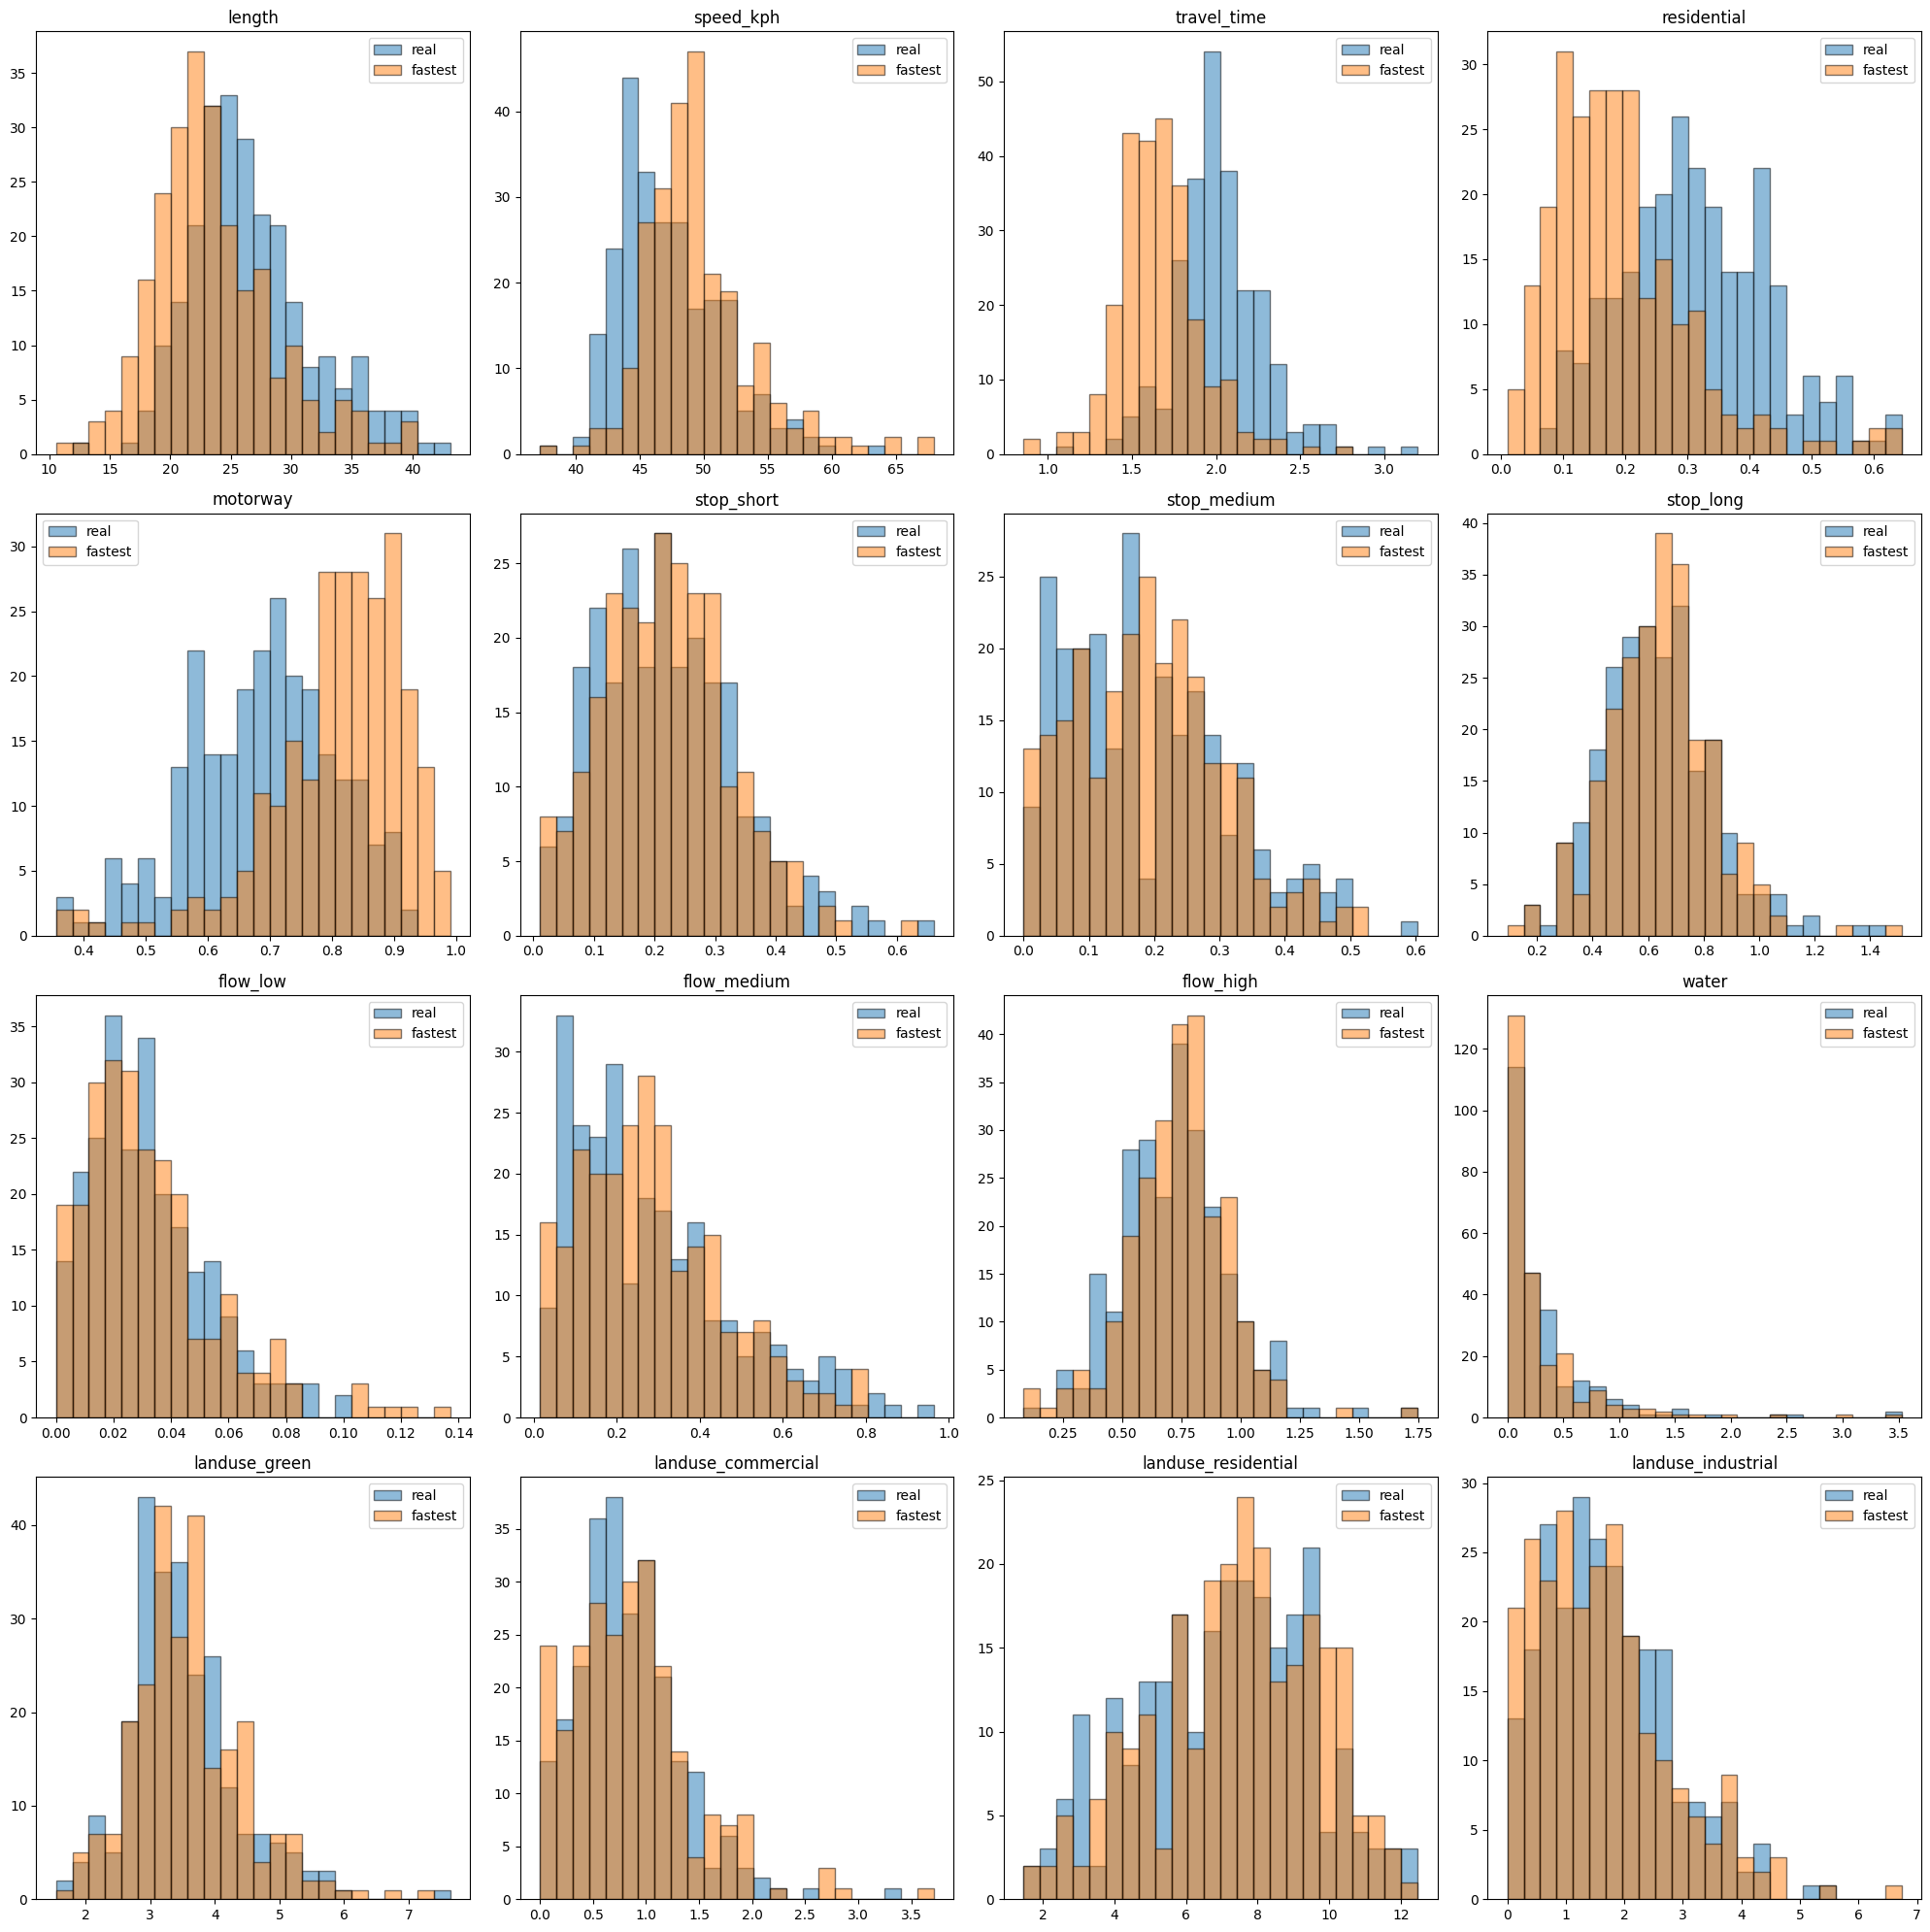

In [ ]:
# Example: plotting histograms of all edge attributes, comparing real vs fastest routes
attributes = [
    'length',
    'speed_kph',
    'travel_time',
    'residential',
    'motorway',
    'stop_short',
    'stop_medium',
    'stop_long',
    'flow_low',
    'flow_medium',
    'flow_high',
    'water',
    'landuse_green',
    'landuse_commercial',
    'landuse_residential',
    'landuse_industrial',
]

real_df_grouped = real_df.groupby('uid')[attributes].mean()
fastest_df_grouped = fastest_df.groupby('uid')[attributes].mean()

fig, ax = plt.subplots(4, 4, figsize=(20,20))
for i, attr in enumerate(attributes):
    real_data = real_df_grouped[attr]
    fastest_data = fastest_df_grouped[attr]

    bins = np.histogram(np.hstack((real_data, fastest_data)), bins=int(3*np.log2(len(real_data))+1))[1]
    
    ax[i//4, i%4].hist(real_data, bins=bins, edgecolor='black', alpha=0.5, label='real')
    ax[i//4, i%4].hist(fastest_data, bins=bins, edgecolor='black', alpha=0.5, label='fastest')
    ax[i//4, i%4].set_title(attr)
    ax[i//4, i%4].legend()

plt.tight_layout()
plt.show()

### Compute real/fastest edge attributes (+ alphas)
To determine where/how fastest routes differ from real routes, we compute, for each user $u$ and each attribute $i$, the relative gap:
$$
    \delta_u^i = \frac{\mu(E_u^{real}, i) - \mu(E_u^{fst}, i)}{\mu(E_u^{fst}, i)} \in [-1, \infty),\\
    \mu(E, i) = \frac{\sum_{e \in E} \phi_i(e)}{|E|}
$$
where $\phi_i(e)$ is the value of attribute $i$ for edge $e$, $E_u^{real}$ the set of edges traversed by the real routes of user $u$, and $E_u^{fst}$ be the set of edges traversed by fastest routes of user $u$.

In [3]:
# Aggregated edge attributes + alphas
# Real data also includes the attributes necessary for clustering
compare_fastest(G,
                routes,
                real_path='data/milano_2007_aggregated_real.csv.gz',
                fastest_path='data/milano_2007_aggregated_fastest.csv.gz',
                alphas_path='data/milano_2007_alphas.json',
                num_processes=1,
                verbose=True)

Users: 100%|██████████| 248/248 [03:50<00:00,  1.08it/s]


In [22]:
df_real = pd.read_csv('data/milano_2007_aggregated_real.csv.gz')
df_fastest = pd.read_csv('data/milano_2007_aggregated_fastest.csv.gz')

gaps = []
for uid in df_real['uid'].unique():
    means_real = df_real[df_real['uid'] == uid][attributes].values[0]
    means_fastest = df_fastest[df_fastest['uid'] == uid][attributes].values[0]

    gap = np.where(means_fastest != 0,
                   (means_real - means_fastest) / means_fastest,
                   np.where(means_real != 0, np.inf, 0))
    gaps.append(gap)
gaps = np.array(gaps)

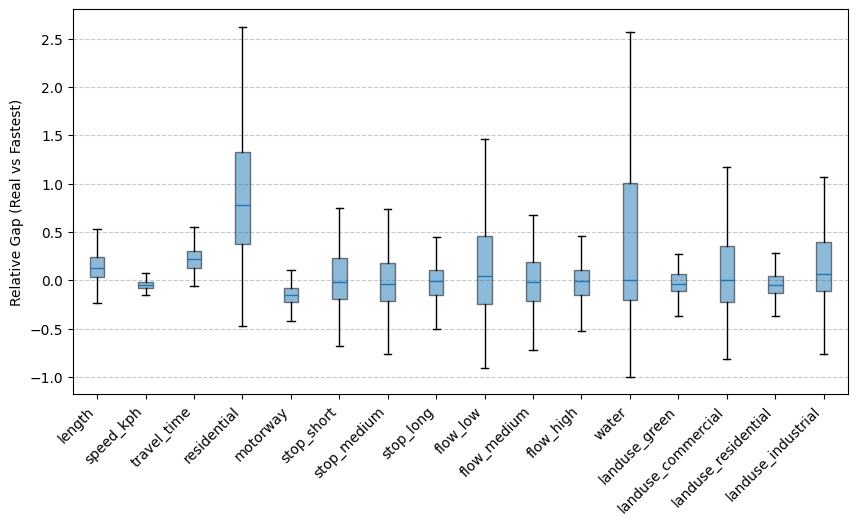

In [23]:
# Plotting the distribution of the relative gaps
plt.figure(figsize=(10, 5))
for i, attr in enumerate(attributes):
    plt.boxplot(gaps[~np.isnan(gaps[:, i]), i], positions=[i], widths=0.3, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor='tab:blue', alpha=0.5),
                medianprops=dict(color='tab:blue'))
plt.xticks(range(len(attributes)), attributes, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel('Relative Gap (Real vs Fastest)')
plt.show()

# Running the search algorithm

In [2]:
G = ox.load_graphml('data/milano_2007_graph.graphml')
routes = read_osmnx_routes('data/milano_2007_routes.csv.gz')

### Testing beta = 1.0

In [10]:
cost_attributes = ['residential', 'landuse_industrial', 'landuse_commercial', 'flow_low', 'water']

In [ ]:
# Can be used for any constant beta: we tested beta=1 to see how cost function behaves
get_adjusted_edge_attributes(G, routes, 1.0, cost_attributes,
                             filename_adjusted='data/milano_2007_allones.csv.gz',
                             filename_alphas='data/milano_2007_alphas.json', verbose=True)

Users: 100%|██████████| 248/248 [01:31<00:00,  2.72it/s]


In [20]:
df_real = pd.read_csv('data/milano_2007_aggregated_real.csv.gz')
df_fastest = pd.read_csv('data/milano_2007_aggregated_fastest.csv.gz')
df_allones = pd.read_csv('data/milano_2007_allones.csv.gz')

gaps_fst = []
gaps_allones = []
for uid in df_real['uid'].unique():
    means_real = df_real[df_real['uid'] == uid][attributes].values[0]
    means_fastest = df_fastest[df_fastest['uid'] == uid][attributes].values[0]
    means_allones = df_allones[df_allones['uid'] == uid][attributes].values[0]

    gap_fst = np.where(means_fastest != 0,
                       (means_real - means_fastest) / means_fastest,
                       np.where(means_real != 0, np.inf, 0))
    gaps_fst.append(gap_fst)

    gap_allones = np.where(means_allones != 0,
                           (means_real - means_allones) / means_allones,
                           np.where(means_real != 0, np.inf, 0))
    gaps_allones.append(gap_allones)

gaps_fst = np.array(gaps_fst)
gaps_allones = np.array(gaps_allones)

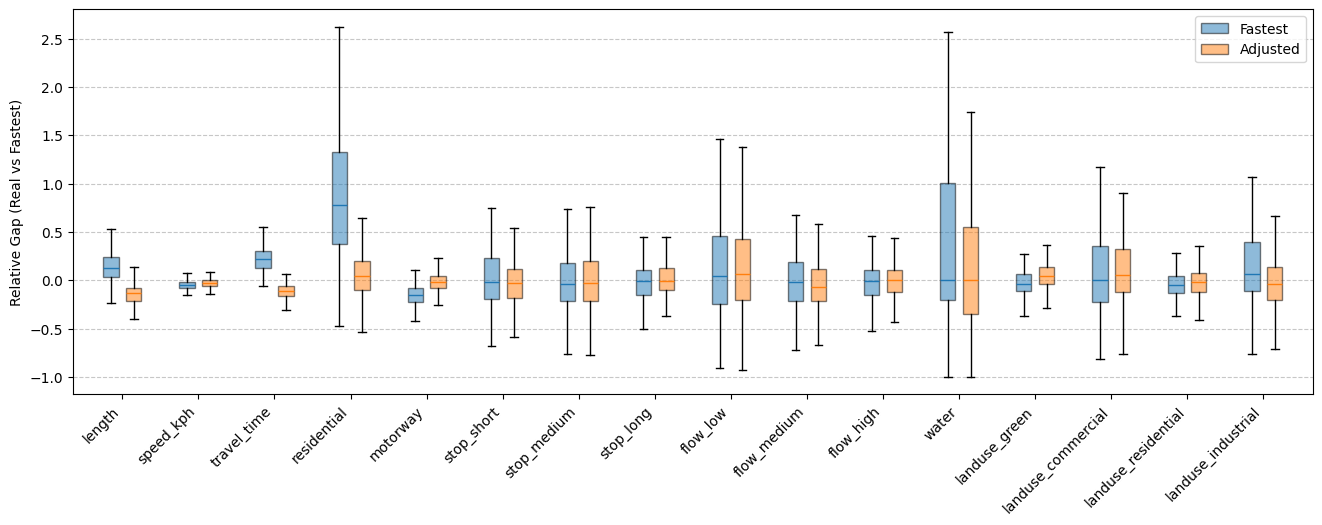

In [ ]:
# Comparing relative gaps, now putting fastest vs adjusted side-by-side
plt.figure(figsize=(16, 5))
for i, attr in enumerate(attributes):
    plt.boxplot(gaps_fst[~np.isnan(gaps_fst[:, i]), i], positions=[i - 0.15], widths=0.2,
                showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor='tab:blue', alpha=0.5),
                medianprops=dict(color='tab:blue'))
    plt.boxplot(gaps_allones[~np.isnan(gaps_allones[:, i]), i], positions=[i + 0.15], widths=0.2, showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor='tab:orange', alpha=0.5),
                medianprops=dict(color='tab:orange'))
    
plt.xticks(range(len(attributes)), attributes, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Fastest', 'Adjusted'])
plt.ylabel('Relative Gap (Real vs Fastest)')
plt.show()

### Identifying clusters
Clustering is done to identify user profiles, i.e., groups of users with similar preferences. The clustering is performed on mean, median, 1st and 3rd quartile of each attribute grouped by user. Clustering algorithm used is hierarchical clustering + ward linkage + euclidean distance

In [3]:
from scipy.cluster.hierarchy import dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [4]:
def get_linkage_matrix(model):
    counts = np.zeros(model.children_.shape[0])
    
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [5]:
# Data contains: mean, median, 1st quartile, 3rd quartile
df_real = pd.read_csv('data/milano_2007_aggregated_real.csv.gz')

# Exclude uid column
X = df_real.drop(columns=['uid']).values
X = StandardScaler().fit_transform(X)

In [6]:
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None, metric='euclidean', linkage='ward')
model.fit(X)

AgglomerativeClustering(distance_threshold=0, n_clusters=None)

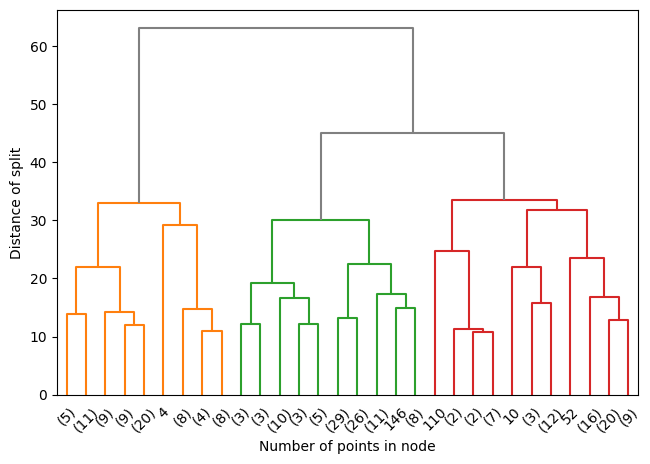

Cluster  1 :  75
Cluster  2 :  99
Cluster  3 :  74


In [ ]:
# Chose to split data into three clusters based on dendrogram

plt.figure(figsize=(7.5,5))
plot_dendrogram(
    model,
    truncate_mode="lastp",
    color_threshold=40,
    above_threshold_color="grey"
)
plt.xlabel("Number of points in node")
plt.ylabel("Distance of split")
plt.show()

t = 40
Z = get_linkage_matrix(model)

labels = fcluster(Z, t=t, criterion='distance')

labels_u, counts = np.unique(labels, return_counts=True)
for l, c in zip(labels_u, counts):
    print('Cluster ', l, ': ', c)

df_real['label'] = labels

In [ ]:
# Mapping each cluster to the uids of the users belonging to that cluster,
# necessary for the iterative algorithm to learn the betas
cluster_to_uid = {cluster: df_real[df_real['label'] == cluster]['uid'].tolist()
                  for cluster in df_real['label'].unique()}

In [ ]:
# All intermediate MAEs + betas are saved to the results_dir
# If cluster_to_uid is not None, each cluster has its own subdirectory

# WARNING: tqdm does not work well with notebooks. Code was written to be run 
# in a script, so progress bars will likely break in a notebook environment.
# This is especially evident for code that produces a lot of bars like this one.
cluster_to_beta = learn_user_preferences(G,
                                         routes,
                                         cost_attributes = ['residential', 'landuse_industrial', 'landuse_commercial', 'flow_low', 'water'],
                                         alphas_path='data/milano_2007_alphas.json',
                                         real_path='data/milano_2007_aggregated_real.csv.gz',
                                         results_dir='data/milano_results/',
                                         iterations=5,
                                         num_processes=2,
                                         cluster_to_uid=cluster_to_uid,
                                         verbose=True)

In [ ]:
# Betas found for each cluster
cluster_to_beta

{np.int32(2): {'residential': np.float64(5.0),
  'landuse_industrial': np.float64(2.5),
  'landuse_commercial': np.float64(0.5),
  'flow_low': np.float64(25.0),
  'water': np.float64(2.5)},
 np.int32(1): {'residential': np.float64(6.25),
  'landuse_industrial': np.float64(5.0),
  'landuse_commercial': np.float64(2.5),
  'flow_low': np.float64(25.0),
  'water': np.float64(2.5)},
 np.int32(3): {'residential': np.float64(5.0),
  'landuse_industrial': np.float64(5.0),
  'landuse_commercial': np.float64(5.0),
  'flow_low': np.float64(50.0),
  'water': np.float64(50.0)}}

### Visualizing results for each cluster

In [26]:
def show_config_results(cluster, cluster_to_uid):
    attributes = [
        'length',
        'speed_kph',
        'travel_time',
        'residential',
        'motorway',
        'stop_short',
        'stop_medium',
        'stop_long',
        'flow_low',
        'flow_medium',
        'flow_high',
        'water',
        'landuse_green',
        'landuse_commercial',
        'landuse_residential',
        'landuse_industrial',
    ]

    cost_attributes = [
        'residential',
        'landuse_industrial',
        'landuse_commercial',
        'flow_low',
        'water',
    ]
    
    data_path = f'data/milano_results/cluster_{cluster}'

    # Pick last iteration results
    gaps_path = None
    for i in range(25,0,-1):
        if os.path.exists(f'{data_path}/gaps_iter_{i}.csv'):
            gaps_path = f'{data_path}/gaps_iter_{i}.csv'
            break
    gaps_adj = pd.read_csv(gaps_path).values.T

    # Read real and fastest data for the cluster to compare
    df_real = pd.read_csv('data/milano_2007_aggregated_real.csv.gz')
    df_fastest = pd.read_csv('data/milano_2007_aggregated_fastest.csv.gz')

    cluster_uids = cluster_to_uid.get(cluster, [])

    df_real = df_real[df_real['uid'].isin(cluster_uids)]
    df_fastest = df_fastest[df_fastest['uid'].isin(cluster_uids)]

    gaps_fst = []
    for uid in cluster_uids:
        xbar_real = df_real[df_real['uid'] == uid][attributes].values[0]
        xbar_opt = df_fastest[df_fastest['uid'] == uid][attributes].values[0]

        gap = np.where(
            xbar_opt != 0.0,
            (xbar_real - xbar_opt) / xbar_opt,
            np.where(
                xbar_real != 0.0,
                np.nan,
                0.0
            )
        )
        gaps_fst.append(gap)
    # Transpose to have attributes as columns, consistent with gaps_adj
    gaps_fst = np.array(gaps_fst).T

    # Print final global MAE
    print("MAE Adjusted:", np.nanmean(np.abs(gaps_adj)))
    print("MAE Fastest:", np.nanmean(np.abs(gaps_fst)))

    ### PLOTTING GAPS VS FASTEST ###
    plt.figure(figsize=(18, 6))
    for i in range(len(attributes)):
        boxplot = plt.boxplot(gaps_fst[i][~np.isnan(gaps_fst[i])], positions=[i-0.15], widths=0.20, patch_artist=True, showfliers=False)
        boxplot['boxes'][0].set_facecolor('tab:blue')
        boxplot['boxes'][0].set_alpha(0.5)
        boxplot['medians'][0].set_color('tab:blue')

        boxplot_adj = plt.boxplot(gaps_adj[i][~np.isnan(gaps_adj[i])], positions=[i+0.15], widths=0.20, patch_artist=True, showfliers=False)
        boxplot_adj['boxes'][0].set_facecolor('tab:orange')
        boxplot_adj['boxes'][0].set_alpha(0.5)
        boxplot_adj['medians'][0].set_color('tab:orange')
    plt.xticks(range(len(attributes)), attributes, rotation=45, ha='right')
    plt.ylabel('Relative gap')
    plt.grid(axis='y', alpha=0.5)
    plt.legend(['Fastest', 'Adjusted'])

    plt.tight_layout()
    plt.show()


    # Plotting MAE by (sub)iteration
    global_maes = []
    for i in range(25):
        filename = f'{data_path}/gaps_iter_{i}.csv'

        if not os.path.exists(filename):
            # Iteration had no improvements
            global_maes.append(np.nan)
        else:
            gaps = pd.read_csv(filename).values
            mae_adj = np.nanmean(np.abs(gaps))
            global_maes.append(mae_adj)
    global_maes = np.array(global_maes)

    plt.figure(figsize=(10, 6))
    plt.plot(np.nonzero(~np.isnan(global_maes))[0],
             global_maes[~np.isnan(global_maes)],
             color='gray')

    # Adding scatter points of alternate colors to distinguish costs
    for i in range(5):
        plt.scatter(np.arange(len(global_maes))[i::5],
                    global_maes[i::5], color=plt.cm.plasma(i/4),
                    zorder=5, label=cost_attributes[i])
    plt.legend()
    plt.xticks(np.arange(max(np.nonzero(~np.isnan(global_maes))[0]) + 1),
               np.arange(1, max(np.nonzero(~np.isnan(global_maes))[0]) + 2))
    plt.title('Global MAE over iterations')
    plt.xlabel('Iteration')
    plt.ylabel('MAE')

    plt.grid(axis='y', alpha=0.5)
    plt.tight_layout()
    plt.show()

CLUSTER 1 RESULTS:
MAE Adjusted: 0.25645871973506057
MAE Fastest: 0.38692190758568806


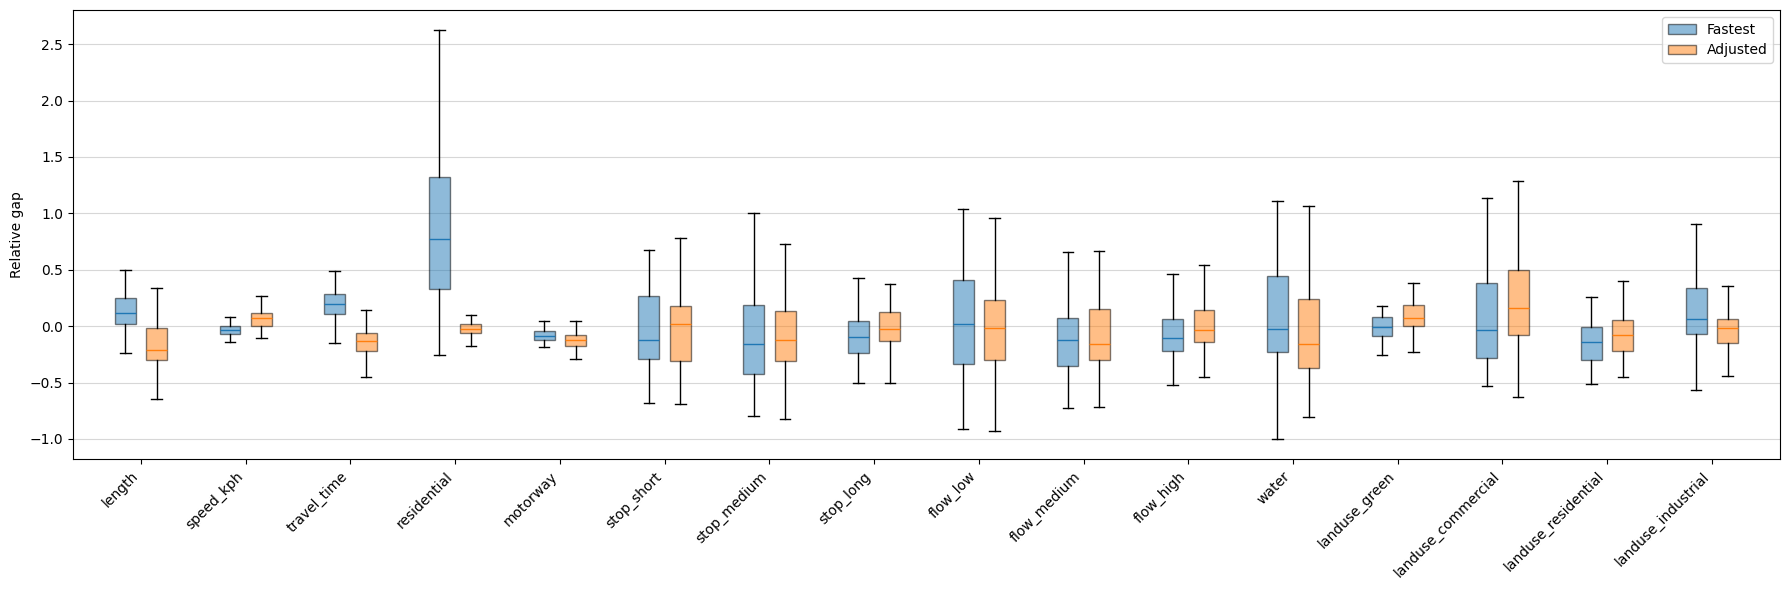

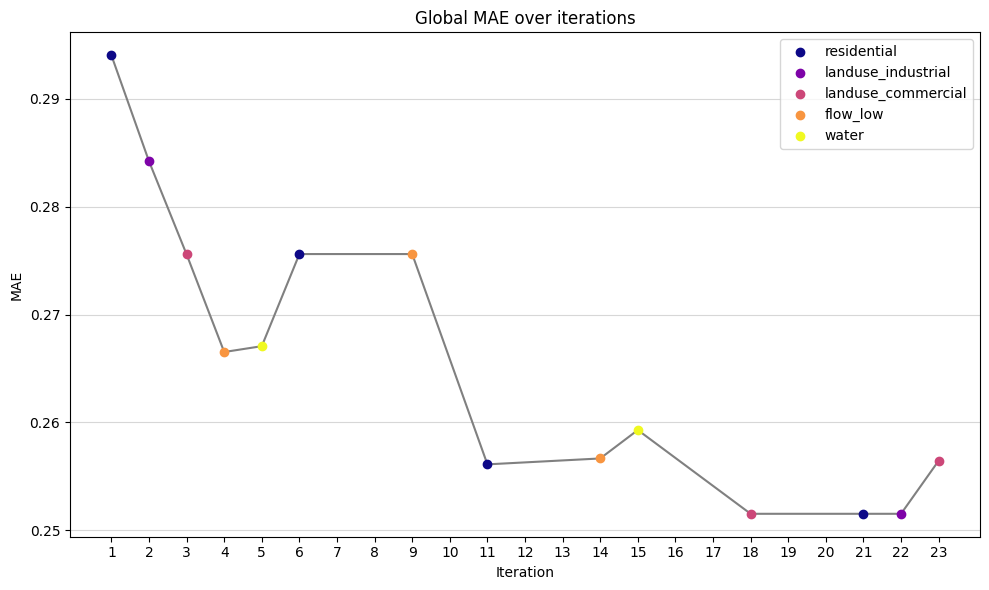

CLUSTER 2 RESULTS:
MAE Adjusted: 0.22426408826741306
MAE Fastest: 0.3439408181122864


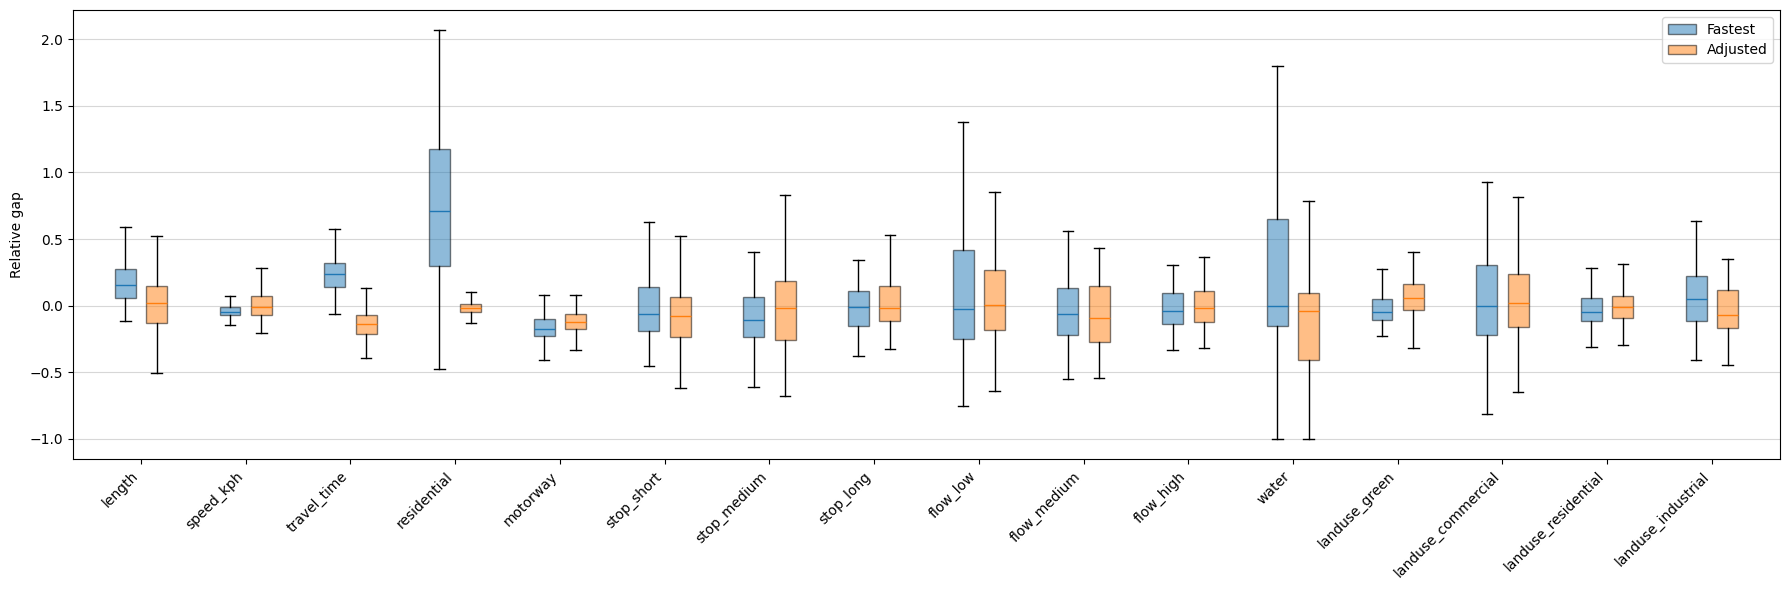

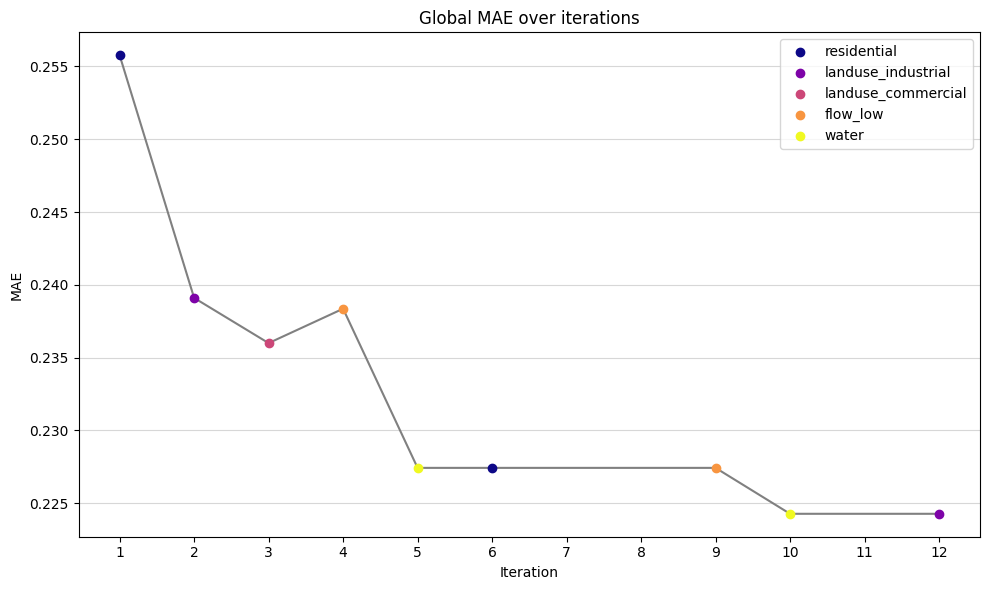

CLUSTER 3 RESULTS:
MAE Adjusted: 0.20758127478483648
MAE Fastest: 0.32312783410509555


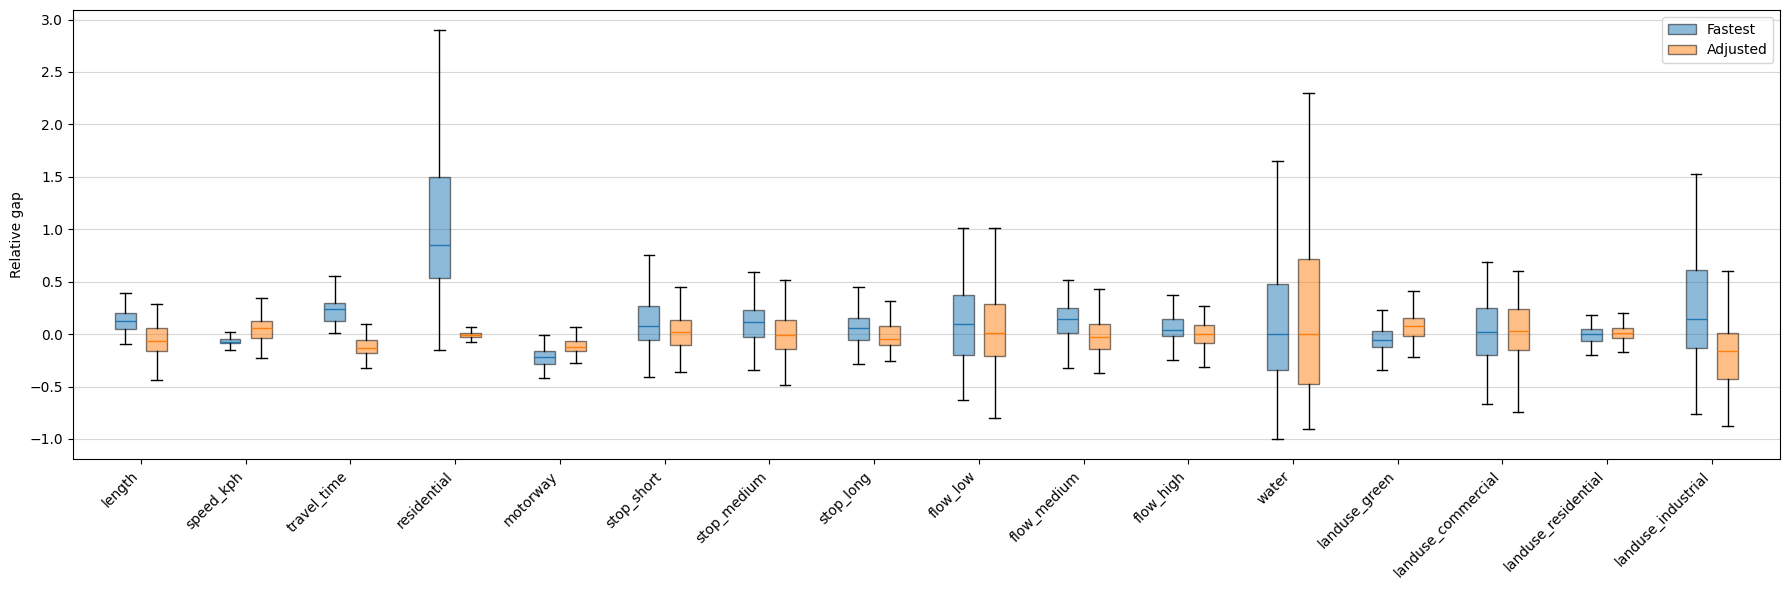

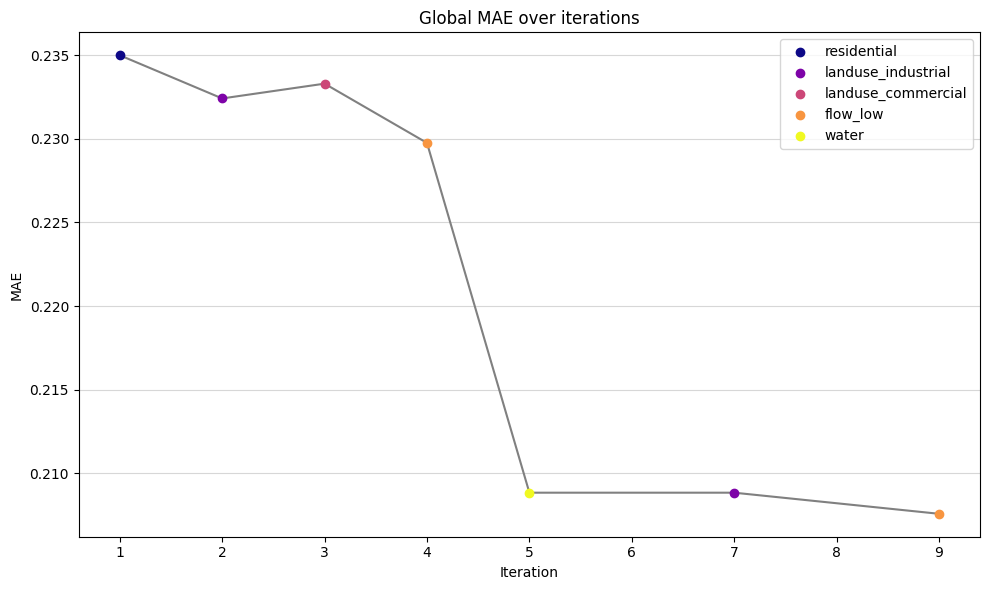

In [27]:
print("CLUSTER 1 RESULTS:")
show_config_results(1, cluster_to_uid)

print("CLUSTER 2 RESULTS:")
show_config_results(2, cluster_to_uid)

print("CLUSTER 3 RESULTS:")
show_config_results(3, cluster_to_uid)